# Fase 3 — Modelo Dimensional (Data Warehouse)
**Proyecto Final — Gestión de Datos (UAX 2025/2026)**

Diseño e implementación del esquema estrella del Data Warehouse.
Metodología **Kimball**: claves subrogadas, grano a nivel de línea de venta,
7 dimensiones y 2 tablas de hechos.

| Elemento | Detalle |
|----------|--------|
| **Schema** | `saleshealth.dwh` |
| **Grano** | 1 fila = 1 línea de venta (`sale_item`) |
| **Dimensiones** | 7: fecha, cliente, producto, tienda, zona, oferta, motivo_devolucion |
| **Hechos** | 2: fact_ventas, fact_devoluciones |

---

## Configuración

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from sqlalchemy import create_engine, text
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

PROJECT_ROOT = Path(r'C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd')
FIGURES_DIR  = PROJECT_ROOT / 'reports' / 'figures'
DOCS_DIR     = PROJECT_ROOT / 'docs' / 'diagramas'
SQL_DIR      = PROJECT_ROOT / 'sql' / 'ddl'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DOCS_DIR.mkdir(parents=True, exist_ok=True)
SQL_DIR.mkdir(parents=True, exist_ok=True)

PALETA = {
    'ERP'       : '#2C6FBF',
    'CRM'       : '#27A06B',
    'Logistica' : '#E07B2A',
    'Postventa' : '#8B4BB8'
}

# Colores para el modelo dimensional
COLOR_FACT = '#1A1A2E'
COLOR_DIM  = '#2C6FBF'

DB_USER     = 'postgres'
DB_PASSWORD = 'pimpum.postgre'
DB_HOST     = 'localhost'
DB_PORT     = '5432'
DB_NAME     = 'saleshealth'

engine = create_engine(
    f'postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
)

def query(sql, params=None):
    with engine.connect() as conn:
        return pd.read_sql_query(text(sql), conn, params=params)

def execute(sql):
    with engine.begin() as conn:
        conn.execute(text(sql))

print('Configuracion lista.')

Configuracion lista.


---
## 1. Creación del schema DWH

In [2]:
# ── Crear schemas stg, dwh y marts si no existen ──────────────────────────────
for schema in ['stg', 'dwh', 'marts']:
    execute(f'CREATE SCHEMA IF NOT EXISTS {schema}')
    print(f'Schema {schema}: OK')

print('\nSchemas creados correctamente.')

Schema stg: OK
Schema dwh: OK
Schema marts: OK

Schemas creados correctamente.


---
## 2. DDL — Dimensiones

Cada dimensión tiene:
- **SK** (Surrogate Key): clave subrogada entera autogenerada — clave primaria del DWH
- **NK** (Natural Key): clave operacional original — para trazabilidad con el origen
- Atributos descriptivos relevantes para el análisis

In [3]:
# ── DDL dimensiones ───────────────────────────────────────────────────────────
DDL_DIMENSIONES = """

-- ── dim_fecha ────────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_fecha CASCADE;
CREATE TABLE dwh.dim_fecha (
    fecha_sk            INTEGER         PRIMARY KEY,  -- YYYYMMDD
    fecha               DATE            NOT NULL,
    anio                SMALLINT        NOT NULL,
    trimestre           SMALLINT        NOT NULL,     -- 1-4
    mes                 SMALLINT        NOT NULL,     -- 1-12
    mes_nombre          VARCHAR(20)     NOT NULL,
    semana              SMALLINT        NOT NULL,     -- 1-53
    dia                 SMALLINT        NOT NULL,     -- 1-31
    dia_semana          SMALLINT        NOT NULL,     -- 1=Lunes ... 7=Domingo
    dia_semana_nombre   VARCHAR(20)     NOT NULL,
    es_fin_de_semana    BOOLEAN         NOT NULL DEFAULT FALSE
);

-- ── dim_cliente ───────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_cliente CASCADE;
CREATE TABLE dwh.dim_cliente (
    cliente_sk          SERIAL          PRIMARY KEY,
    cliente_nk          INTEGER         NOT NULL,     -- customer.customer_id
    nombre              VARCHAR(100),
    apellido            VARCHAR(100),
    apellido2           VARCHAR(100),
    email               VARCHAR(200),
    telefono            VARCHAR(20),
    fecha_alta          TIMESTAMP,
    -- Dimension especial para clientes sin datos
    es_desconocido      BOOLEAN         NOT NULL DEFAULT FALSE
);

-- ── dim_producto ──────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_producto CASCADE;
CREATE TABLE dwh.dim_producto (
    producto_sk         SERIAL          PRIMARY KEY,
    producto_nk         INTEGER         NOT NULL,     -- product.product_id
    nombre              VARCHAR(200)    NOT NULL,
    categoria           VARCHAR(100),
    marca               VARCHAR(100),
    precio_venta        NUMERIC(10,2),
    coste_unitario      NUMERIC(10,2),
    margen_pct          NUMERIC(6,2),
    sku                 VARCHAR(50),
    coste_imputado      BOOLEAN         NOT NULL DEFAULT FALSE  -- flag producto 29
);

-- ── dim_tienda ────────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_tienda CASCADE;
CREATE TABLE dwh.dim_tienda (
    tienda_sk           SERIAL          PRIMARY KEY,
    tienda_nk           INTEGER         NOT NULL,     -- store.store_id
    nombre              VARCHAR(100)    NOT NULL,
    direccion           VARCHAR(200),
    ciudad              VARCHAR(100),
    codigo_postal       VARCHAR(10),
    latitud             NUMERIC(10,6),
    longitud            NUMERIC(10,6)
);

-- ── dim_zona ─────────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_zona CASCADE;
CREATE TABLE dwh.dim_zona (
    zona_sk             SERIAL          PRIMARY KEY,
    codigo_postal       VARCHAR(10)     NOT NULL,     -- city_zone.postal_code (NK)
    distrito            VARCHAR(100),
    tipo_area           VARCHAR(50),                  -- Centrica / Periferica
    orientacion         VARCHAR(50),                  -- Norte / Sur / Este / Oeste
    ciudad              VARCHAR(100),
    es_desconocida      BOOLEAN         NOT NULL DEFAULT FALSE
);

-- ── dim_oferta ────────────────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_oferta CASCADE;
CREATE TABLE dwh.dim_oferta (
    oferta_sk           SERIAL          PRIMARY KEY,
    oferta_nk           INTEGER,                      -- offer.offer_id (NULL = sin oferta)
    nombre              VARCHAR(200)    NOT NULL,
    descripcion         TEXT,
    descuento_pct       NUMERIC(5,2),
    fecha_inicio        DATE,
    fecha_fin           DATE,
    es_sin_oferta       BOOLEAN         NOT NULL DEFAULT FALSE
);

-- ── dim_motivo_devolucion ─────────────────────────────────────────────────────
DROP TABLE IF EXISTS dwh.dim_motivo_devolucion CASCADE;
CREATE TABLE dwh.dim_motivo_devolucion (
    motivo_sk           SERIAL          PRIMARY KEY,
    motivo_nk           INTEGER,                      -- return_reason.reason_id
    motivo              VARCHAR(200)    NOT NULL,
    activo              BOOLEAN         NOT NULL DEFAULT TRUE,
    es_desconocido      BOOLEAN         NOT NULL DEFAULT FALSE
);

"""

# Ejecutar DDL
for stmt in DDL_DIMENSIONES.strip().split(';\n'):
    stmt = stmt.strip()
    if stmt and not stmt.startswith('--'):
        execute(stmt + ';')

# Verificar
dims = query("""
    SELECT table_name, 
           (SELECT COUNT(*) FROM information_schema.columns c2
            WHERE c2.table_schema = 'dwh' AND c2.table_name = t.table_name) AS columnas
    FROM information_schema.tables t
    WHERE table_schema = 'dwh' AND table_name LIKE 'dim_%'
    ORDER BY table_name
""")

print('Dimensiones creadas:')
print('=' * 40)
for _, row in dims.iterrows():
    print(f'  {row["table_name"]:<30} {int(row["columnas"]):>3} columnas')
print('=' * 40)
print(f'Total: {len(dims)} dimensiones')

Dimensiones creadas:
  dim_cliente                      9 columnas
  dim_fecha                       11 columnas
  dim_motivo_devolucion            5 columnas
  dim_oferta                       8 columnas
  dim_producto                    10 columnas
  dim_tienda                       8 columnas
  dim_zona                         7 columnas
Total: 7 dimensiones


---
## 3. DDL — Tablas de hechos

In [4]:
# ── DDL tablas de hechos ──────────────────────────────────────────────────────
DDL_HECHOS = """

-- ── fact_ventas ───────────────────────────────────────────────────────────────
-- Grano: 1 fila = 1 linea de venta (sale_item)
DROP TABLE IF EXISTS dwh.fact_ventas CASCADE;
CREATE TABLE dwh.fact_ventas (
    -- Claves subrogadas (FKs a dimensiones)
    fecha_sk            INTEGER         NOT NULL REFERENCES dwh.dim_fecha(fecha_sk),
    cliente_sk          INTEGER         NOT NULL REFERENCES dwh.dim_cliente(cliente_sk),
    producto_sk         INTEGER         NOT NULL REFERENCES dwh.dim_producto(producto_sk),
    tienda_sk           INTEGER         NOT NULL REFERENCES dwh.dim_tienda(tienda_sk),
    zona_sk             INTEGER         NOT NULL REFERENCES dwh.dim_zona(zona_sk),
    oferta_sk           INTEGER         NOT NULL REFERENCES dwh.dim_oferta(oferta_sk),
    -- Claves naturales (trazabilidad al origen)
    sale_id             INTEGER         NOT NULL,
    sale_item_id        INTEGER         NOT NULL,
    -- Metricas
    cantidad            INTEGER         NOT NULL,
    precio_unitario     NUMERIC(10,2)   NOT NULL,
    subtotal_bruto      NUMERIC(10,2)   NOT NULL,   -- cantidad * precio_unitario
    coste_total         NUMERIC(10,2),              -- cantidad * coste_unitario
    margen_bruto        NUMERIC(10,2),              -- subtotal_bruto - coste_total
    margen_pct          NUMERIC(6,2),               -- margen_bruto / subtotal_bruto * 100
    -- Flag de devolucion (para CLTV neto sin JOIN a fact_devoluciones)
    es_devuelta         BOOLEAN         NOT NULL DEFAULT FALSE,
    cantidad_devuelta   INTEGER         NOT NULL DEFAULT 0,
    subtotal_neto       NUMERIC(10,2),              -- subtotal_bruto ajustado por devoluciones
    -- Clave primaria compuesta
    PRIMARY KEY (sale_item_id)
);

-- ── fact_devoluciones ─────────────────────────────────────────────────────────
-- Grano: 1 fila = 1 devolucion (return_item)
DROP TABLE IF EXISTS dwh.fact_devoluciones CASCADE;
CREATE TABLE dwh.fact_devoluciones (
    -- Claves subrogadas
    fecha_sk            INTEGER         NOT NULL REFERENCES dwh.dim_fecha(fecha_sk),
    cliente_sk          INTEGER         NOT NULL REFERENCES dwh.dim_cliente(cliente_sk),
    producto_sk         INTEGER         NOT NULL REFERENCES dwh.dim_producto(producto_sk),
    tienda_sk           INTEGER         NOT NULL REFERENCES dwh.dim_tienda(tienda_sk),
    motivo_sk           INTEGER         NOT NULL REFERENCES dwh.dim_motivo_devolucion(motivo_sk),
    -- Claves naturales
    return_id           INTEGER         NOT NULL,
    sale_item_id        INTEGER         NOT NULL,   -- referencia al item original
    -- Metricas
    cantidad_devuelta   INTEGER         NOT NULL,
    importe_devuelto    NUMERIC(10,2),              -- cantidad_devuelta * precio_unitario
    coste_devuelto      NUMERIC(10,2),              -- cantidad_devuelta * coste_unitario
    -- Clave primaria
    PRIMARY KEY (return_id)
);

"""

for stmt in DDL_HECHOS.strip().split(';\n'):
    stmt = stmt.strip()
    if stmt and not stmt.startswith('--'):
        execute(stmt + ';')

# Verificar
hechos = query("""
    SELECT table_name,
           (SELECT COUNT(*) FROM information_schema.columns c2
            WHERE c2.table_schema = 'dwh' AND c2.table_name = t.table_name) AS columnas
    FROM information_schema.tables t
    WHERE table_schema = 'dwh' AND table_name LIKE 'fact_%'
    ORDER BY table_name
""")

print('Tablas de hechos creadas:')
print('=' * 40)
for _, row in hechos.iterrows():
    print(f'  {row["table_name"]:<30} {int(row["columnas"]):>3} columnas')
print('=' * 40)
print(f'Total: {len(hechos)} tablas de hechos')

Tablas de hechos creadas:
  fact_devoluciones               10 columnas
  fact_ventas                     17 columnas
Total: 2 tablas de hechos


---
## 4. Guardar DDL en sql/ddl/

In [5]:
# ── Guardar DDL completo en sql/ddl/ ─────────────────────────────────────────
DDL_COMPLETO = f"""-- ============================================================
-- DDL Data Warehouse — saleshealth
-- Schema: dwh
-- Metodologia: Kimball (esquema estrella)
-- Grano: 1 fila = 1 linea de venta (sale_item)
-- ============================================================

-- Crear schema
CREATE SCHEMA IF NOT EXISTS dwh;
CREATE SCHEMA IF NOT EXISTS stg;
CREATE SCHEMA IF NOT EXISTS marts;
{DDL_DIMENSIONES}
{DDL_HECHOS}
"""

ddl_path = SQL_DIR / '01_dwh_schema.sql'
ddl_path.write_text(DDL_COMPLETO, encoding='utf-8')

print(f'DDL guardado en: {ddl_path}')

DDL guardado en: C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\sql\ddl\01_dwh_schema.sql


---
## 5. Diagrama del modelo dimensional

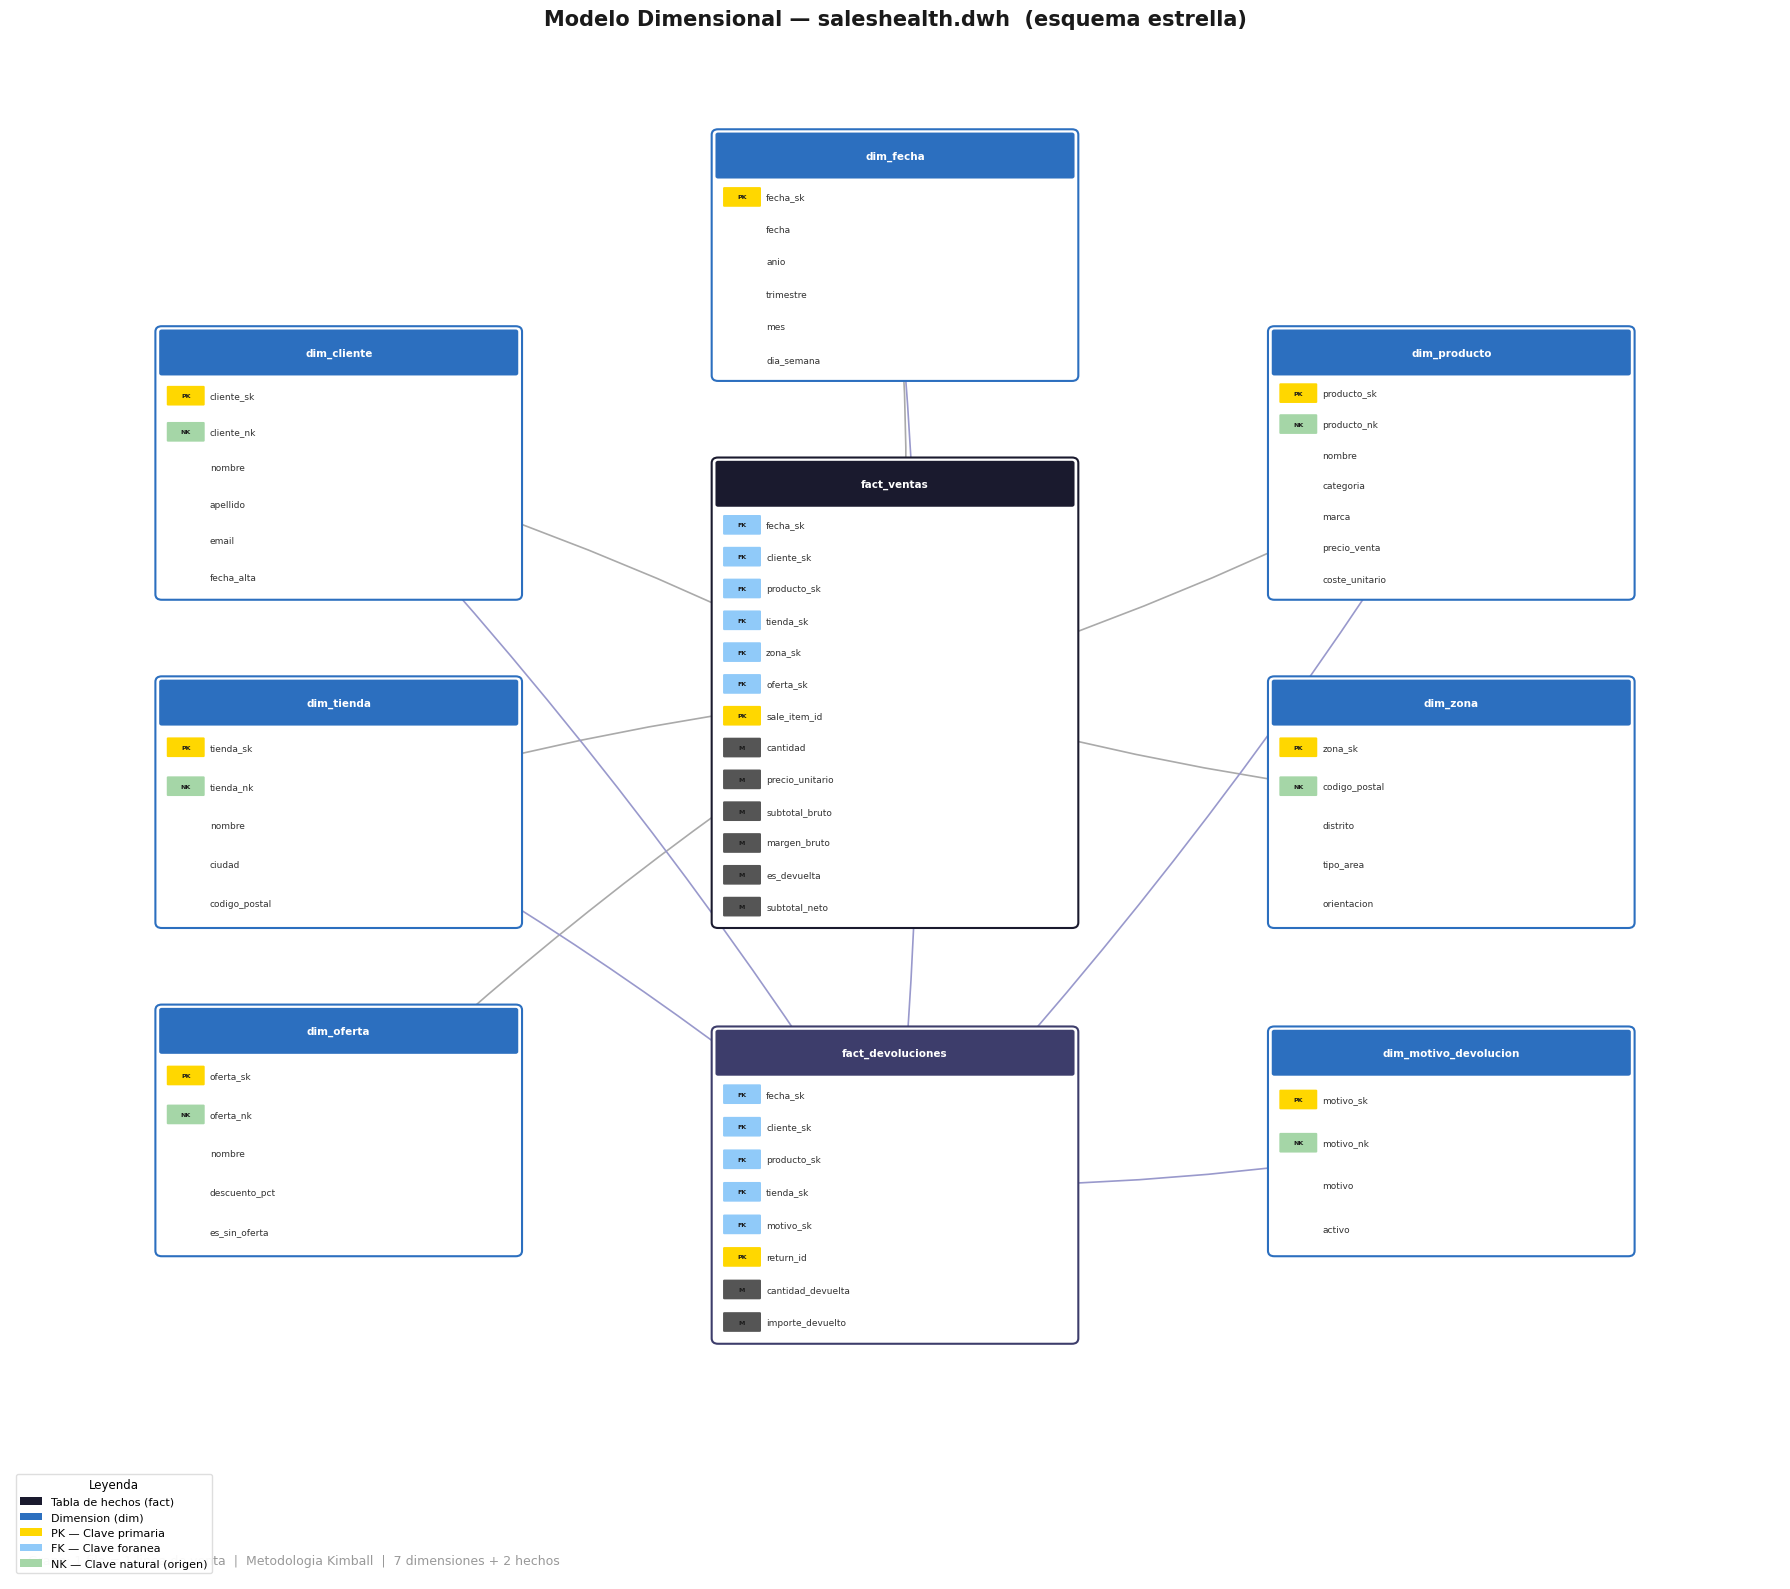


Diagrama guardado en:
   C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\reports\figures\16_modelo_dimensional.png
   C:\Users\Propietario\Desktop\segundo cuatri\gestion de datos\trabajo final gd\docs\diagramas\modelo_dimensional.png


In [8]:
# ── Diagrama esquema estrella ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 16))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')
ax.set_xlim(-1, 13)
ax.set_ylim(-1, 13)
ax.axis('off')

TABLAS = {
    # Centro superior: fact_ventas
    'fact_ventas': {
        'pos': (4.6, 5.0), 'color': COLOR_FACT, 'w': 2.8, 'h': 4.2,
        'cols': [
            ('fecha_sk', 'FK'), ('cliente_sk', 'FK'), ('producto_sk', 'FK'),
            ('tienda_sk', 'FK'), ('zona_sk', 'FK'), ('oferta_sk', 'FK'),
            ('sale_item_id', 'PK'), ('cantidad', 'M'), ('precio_unitario', 'M'),
            ('subtotal_bruto', 'M'), ('margen_bruto', 'M'),
            ('es_devuelta', 'M'), ('subtotal_neto', 'M'),
        ]
    },
    # Centro inferior: fact_devoluciones
    'fact_devoluciones': {
        'pos': (4.6, 1.2), 'color': '#3D3D6B', 'w': 2.8, 'h': 2.8,
        'cols': [
            ('fecha_sk', 'FK'), ('cliente_sk', 'FK'), ('producto_sk', 'FK'),
            ('tienda_sk', 'FK'), ('motivo_sk', 'FK'),
            ('return_id', 'PK'), ('cantidad_devuelta', 'M'), ('importe_devuelto', 'M'),
        ]
    },
    # Arriba centro: dim_fecha
    'dim_fecha': {
        'pos': (4.6, 10.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.2,
        'cols': [('fecha_sk','PK'),('fecha',''),('anio',''),('trimestre',''),('mes',''),('dia_semana','')]
    },
    # Izquierda arriba: dim_cliente
    'dim_cliente': {
        'pos': (0.2, 8.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.4,
        'cols': [('cliente_sk','PK'),('cliente_nk','NK'),('nombre',''),('apellido',''),('email',''),('fecha_alta','')]
    },
    # Derecha arriba: dim_producto
    'dim_producto': {
        'pos': (9.0, 8.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.4,
        'cols': [('producto_sk','PK'),('producto_nk','NK'),('nombre',''),('categoria',''),('marca',''),('precio_venta',''),('coste_unitario','')]
    },
    # Izquierda centro: dim_tienda
    'dim_tienda': {
        'pos': (0.2, 5.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.2,
        'cols': [('tienda_sk','PK'),('tienda_nk','NK'),('nombre',''),('ciudad',''),('codigo_postal','')]
    },
    # Derecha centro: dim_zona
    'dim_zona': {
        'pos': (9.0, 5.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.2,
        'cols': [('zona_sk','PK'),('codigo_postal','NK'),('distrito',''),('tipo_area',''),('orientacion','')]
    },
    # Izquierda abajo: dim_oferta
    'dim_oferta': {
        'pos': (0.2, 2.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.2,
        'cols': [('oferta_sk','PK'),('oferta_nk','NK'),('nombre',''),('descuento_pct',''),('es_sin_oferta','')]
    },
    # Derecha abajo: dim_motivo_devolucion
    'dim_motivo_devolucion': {
        'pos': (9.0, 2.0), 'color': COLOR_DIM, 'w': 2.8, 'h': 2.0,
        'cols': [('motivo_sk','PK'),('motivo_nk','NK'),('motivo',''),('activo','')]
    },
}

tabla_centros = {}
for nombre, t in TABLAS.items():
    x, y  = t['pos']
    w, h  = t['w'], t['h']
    color = t['color']
    cx, cy = x + w/2, y + h/2
    tabla_centros[nombre] = (cx, cy)

    rect = mpatches.FancyBboxPatch(
        (x, y), w, h, boxstyle='round,pad=0.05',
        linewidth=1.5, edgecolor=color, facecolor='white', zorder=2
    )
    ax.add_patch(rect)

    header = mpatches.FancyBboxPatch(
        (x, y + h - 0.38), w, 0.38, boxstyle='round,pad=0.02',
        linewidth=0, edgecolor=color, facecolor=color, zorder=3
    )
    ax.add_patch(header)
    ax.text(cx, y + h - 0.19, nombre,
            ha='center', va='center', fontsize=7.5,
            fontweight='bold', color='white', zorder=4)

    row_h = (h - 0.42) / max(len(t['cols']), 1)
    for j, (col, tipo) in enumerate(t['cols']):
        row_y = y + h - 0.42 - (j + 0.5) * row_h
        col_color = '#FFD700' if tipo == 'PK' else ('#90CAF9' if tipo == 'FK' else ('#A5D6A7' if tipo == 'NK' else '#555555'))
        if tipo in ('PK', 'FK', 'NK', 'M'):
            badge = mpatches.FancyBboxPatch(
                (x + 0.05, row_y - 0.08), 0.28, 0.16,
                boxstyle='round,pad=0.01', linewidth=0,
                facecolor=col_color, zorder=4
            )
            ax.add_patch(badge)
            ax.text(x + 0.19, row_y, tipo,
                    ha='center', va='center', fontsize=4.5,
                    fontweight='bold', color='#1A1A1A', zorder=5)
        ax.text(x + 0.38, row_y, col,
                ha='left', va='center', fontsize=6.5,
                color='#333333', zorder=4)

CONEXIONES_VENTAS = [
    ('fact_ventas', 'dim_fecha'),
    ('fact_ventas', 'dim_cliente'),
    ('fact_ventas', 'dim_producto'),
    ('fact_ventas', 'dim_tienda'),
    ('fact_ventas', 'dim_zona'),
    ('fact_ventas', 'dim_oferta'),
]
CONEXIONES_DEV = [
    ('fact_devoluciones', 'dim_fecha'),
    ('fact_devoluciones', 'dim_cliente'),
    ('fact_devoluciones', 'dim_producto'),
    ('fact_devoluciones', 'dim_tienda'),
    ('fact_devoluciones', 'dim_motivo_devolucion'),
]

for origen, destino in CONEXIONES_VENTAS + CONEXIONES_DEV:
    x1, y1 = tabla_centros[origen]
    x2, y2 = tabla_centros[destino]
    color_line = '#AAAAAA' if origen == 'fact_ventas' else '#9999CC'
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(
                    arrowstyle='-|>', color=color_line,
                    lw=1.2, connectionstyle='arc3,rad=0.05'
                ), zorder=1)

leyenda = [
    mpatches.Patch(facecolor=COLOR_FACT, label='Tabla de hechos (fact)'),
    mpatches.Patch(facecolor=COLOR_DIM,  label='Dimension (dim)'),
    mpatches.Patch(facecolor='#FFD700',  label='PK — Clave primaria'),
    mpatches.Patch(facecolor='#90CAF9',  label='FK — Clave foranea'),
    mpatches.Patch(facecolor='#A5D6A7',  label='NK — Clave natural (origen)'),
]
ax.legend(handles=leyenda, loc='lower left', fontsize=8,
          frameon=True, framealpha=0.95, edgecolor='#DDDDDD',
          title='Leyenda', title_fontsize=8.5)

ax.set_title('Modelo Dimensional — saleshealth.dwh  (esquema estrella)',
             fontsize=15, fontweight='bold', color='#1A1A1A', pad=16)
ax.text(0.01, 0.01,
        'Grano: 1 fila = 1 linea de venta  |  Metodologia Kimball  |  7 dimensiones + 2 hechos',
        transform=ax.transAxes, fontsize=9, color='#999999')

plt.tight_layout()
plt.savefig(FIGURES_DIR / '16_modelo_dimensional.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.savefig(DOCS_DIR / 'modelo_dimensional.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

print(f'\nDiagrama guardado en:')
print(f'   {FIGURES_DIR / "16_modelo_dimensional.png"}')
print(f'   {DOCS_DIR / "modelo_dimensional.png"}')

---
## 6. Resumen del modelo dimensional

In [9]:
# ── Resumen completo ──────────────────────────────────────────────────────────
todas = query("""
    SELECT table_name,
           (SELECT COUNT(*) FROM information_schema.columns c2
            WHERE c2.table_schema = 'dwh' AND c2.table_name = t.table_name) AS columnas
    FROM information_schema.tables t
    WHERE table_schema = 'dwh'
    ORDER BY table_name
""")

print('=' * 62)
print('  MODELO DIMENSIONAL — saleshealth.dwh')
print('  Metodologia: Kimball (esquema estrella)')
print('  Grano: 1 fila = 1 linea de venta (sale_item)')
print('=' * 62)
print(f'\n  DIMENSIONES')
print(f'  {"TABLA":<30} {"COLUMNAS":>8}  FUENTE OPERACIONAL')
print('  ' + '-' * 55)

fuentes = {
    'dim_fecha'              : 'Generada (rango de ventas)',
    'dim_cliente'            : 'customer',
    'dim_producto'           : 'product + central_product',
    'dim_tienda'             : 'store',
    'dim_zona'               : 'city_zone',
    'dim_oferta'             : 'offer',
    'dim_motivo_devolucion'  : 'return_reason',
    'fact_ventas'            : 'sale + sale_item + return_item',
    'fact_devoluciones'      : 'return_item + sale_item',
}

for _, row in todas.iterrows():
    tipo = 'HECHO  ' if row['table_name'].startswith('fact') else 'DIM    '
    fuente = fuentes.get(row['table_name'], '')
    if row['table_name'].startswith('fact'):
        continue
    print(f'  {row["table_name"]:<30} {int(row["columnas"]):>8}  {fuente}')

print(f'\n  HECHOS')
print(f'  {"TABLA":<30} {"COLUMNAS":>8}  FUENTE OPERACIONAL')
print('  ' + '-' * 55)
for _, row in todas.iterrows():
    if not row['table_name'].startswith('fact'):
        continue
    fuente = fuentes.get(row['table_name'], '')
    print(f'  {row["table_name"]:<30} {int(row["columnas"]):>8}  {fuente}')

print('=' * 62)
dims_count  = len(todas[todas['table_name'].str.startswith('dim_')])
facts_count = len(todas[todas['table_name'].str.startswith('fact_')])
print(f'  Dimensiones : {dims_count}')
print(f'  Hechos      : {facts_count}')
print(f'  DDL guardado: sql/ddl/01_dwh_schema.sql')
print('=' * 62)
print('\nFase 3 — Modelo Dimensional completada.')

  MODELO DIMENSIONAL — saleshealth.dwh
  Metodologia: Kimball (esquema estrella)
  Grano: 1 fila = 1 linea de venta (sale_item)

  DIMENSIONES
  TABLA                          COLUMNAS  FUENTE OPERACIONAL
  -------------------------------------------------------
  dim_cliente                           9  customer
  dim_fecha                            11  Generada (rango de ventas)
  dim_motivo_devolucion                 5  return_reason
  dim_oferta                            8  offer
  dim_producto                         10  product + central_product
  dim_tienda                            8  store
  dim_zona                              7  city_zone

  HECHOS
  TABLA                          COLUMNAS  FUENTE OPERACIONAL
  -------------------------------------------------------
  fact_devoluciones                    10  return_item + sale_item
  fact_ventas                          17  sale + sale_item + return_item
  Dimensiones : 7
  Hechos      : 2
  DDL guardado: sql/ddl/01_dwh_